[08:02:24] 処理開始
[08:02:24] 探索ディレクトリ d:\musashino-university\security-tokuron\2025\TorIP-wivern\PD\csv-2026-03-12
[08:02:24] 探索中 ./csv-2026-03-12
[08:02:24] CSV発見 ./csv-2026-03-12\2025-10-24_21-36-23_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-10-25_03-00-01_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-10-26_03-00-01_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-10-27_03-00-01_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-10-28_03-00-02_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-10-29_03-00-01_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-10-30_03-00-02_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-10-31_03-00-01_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-11-01_03-00-02_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-11-02_03-00-01_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-11-03_03-00-01_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-11-04_03-00-01_geocoded.csv
[08:02:24] CSV発見 ./csv-2026-03-12\2025-11-05_03-00-

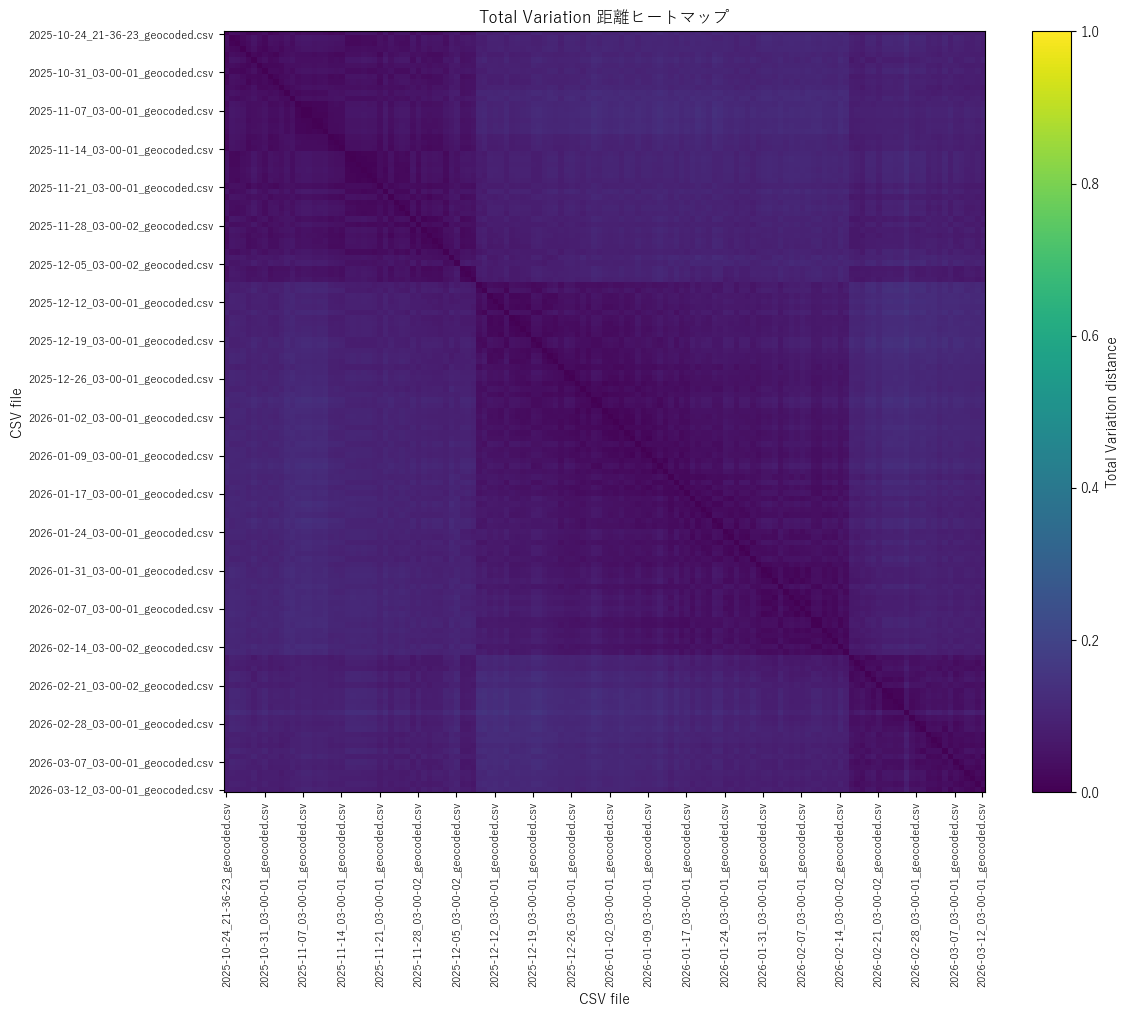

[08:02:32] 隣接距離計算
[08:02:32] 1/138 dist=0.039461
[08:02:32] 2/138 dist=0.011697
[08:02:32] 3/138 dist=0.020047
[08:02:32] 4/138 dist=0.027923
[08:02:32] 5/138 dist=0.025656
[08:02:32] 6/138 dist=0.033094
[08:02:32] 7/138 dist=0.022377
[08:02:32] 8/138 dist=0.030174
[08:02:32] 9/138 dist=0.019371
[08:02:32] 10/138 dist=0.024698
[08:02:32] 11/138 dist=0.024894
[08:02:32] 12/138 dist=0.034138
[08:02:32] 13/138 dist=0.038038
[08:02:32] 14/138 dist=0.011813
[08:02:32] 15/138 dist=0.003648
[08:02:32] 16/138 dist=0.012898
[08:02:32] 17/138 dist=0.007096
[08:02:32] 18/138 dist=0.014678
[08:02:32] 19/138 dist=0.027512
[08:02:32] 20/138 dist=0.011463
[08:02:32] 21/138 dist=0.011435
[08:02:32] 22/138 dist=0.037864
[08:02:32] 23/138 dist=0.006474
[08:02:32] 24/138 dist=0.008020
[08:02:32] 25/138 dist=0.008833
[08:02:32] 26/138 dist=0.010020
[08:02:32] 27/138 dist=0.010253
[08:02:32] 28/138 dist=0.026409
[08:02:32] 29/138 dist=0.038551
[08:02:32] 30/138 dist=0.043295
[08:02:32] 31/138 dist=0.032949

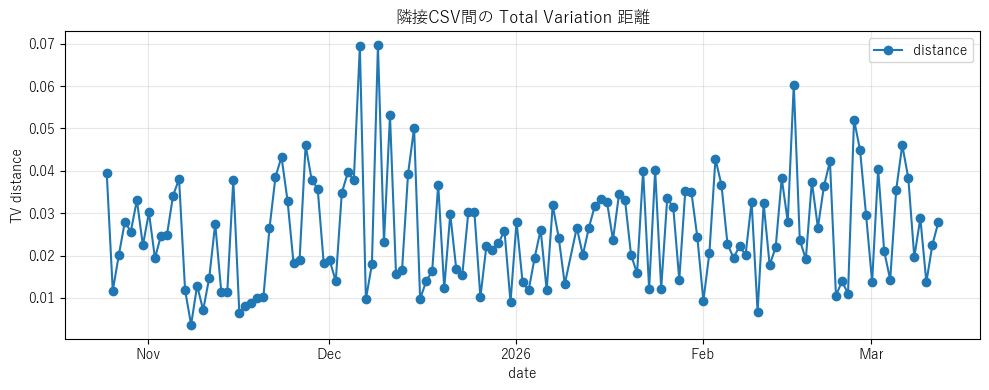

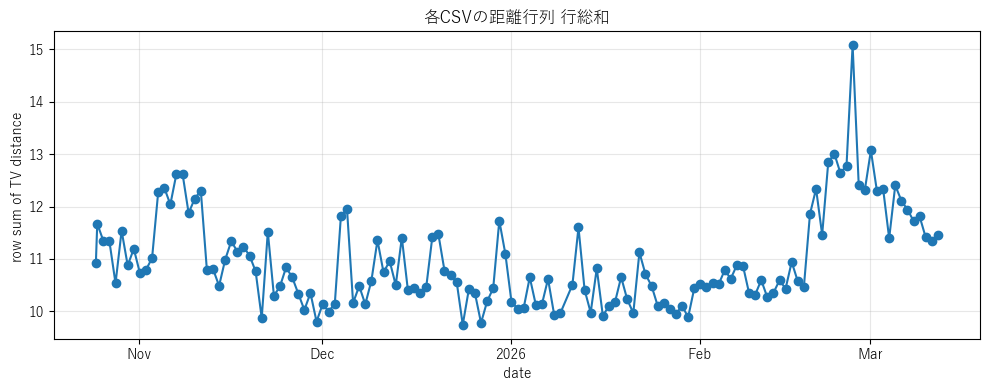

[08:02:34] 変化上位
[08:02:34] 1 2025-12-09 03:00:01 dist=0.069638 z=3.20
[08:02:34] 2 2025-12-06 03:00:01 dist=0.069412 z=3.18
[08:02:34] 3 2026-02-16 03:00:01 dist=0.060365 z=2.55
[08:02:34] 4 2025-12-11 03:00:02 dist=0.053067 z=2.04
[08:02:34] 5 2026-02-26 03:00:02 dist=0.052093 z=1.97
[08:02:34] 6 2025-12-15 03:00:01 dist=0.050109 z=1.83
[08:02:34] 7 2025-11-27 03:00:01 dist=0.046111 z=1.55
[08:02:34] 8 2026-03-06 03:00:01 dist=0.046057 z=1.55
[08:02:34] 9 2026-02-27 03:00:01 dist=0.044855 z=1.46
[08:02:34] 10 2025-11-23 03:00:01 dist=0.043295 z=1.35
[08:02:34] 外れ値
[08:02:34] 外れ値なし
[08:02:34] 完了 総時間 00:10.32


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
指定ディレクトリ内のすべてのCSVを読み込み、
緯度(lat)・経度(lon)分布の Total Variation 距離を計算する

出力
1 距離行列 CSV
2 距離ヒートマップ PNG
3 隣接ペア時系列 CSV
4 隣接ペア時系列 PNG
5 行総和 PNG

特徴
・ディレクトリを再帰探索
・全CSV対象
・途中経過詳細表示
・Excel互換 cp932 出力
・ヒートマップ軸ラベル自動間引き
・PNG保存に加えて画面表示も行う
・2番目の図で外れ値に赤丸を付与
・lat/lon を 2次元ヒストグラム化して Total Variation 距離を計算
"""

# ========= 設定 =========

DATA_DIR = r"./csv-2026-03-12"
PREFIX = "total_variation"

MIN_ROWS = 1
OUTPUT_ENCODING = "cp932"
PAIR_PROGRESS_STEP = 10

HEATMAP_MAX_LABELS = 20
HEATMAP_FONT_SIZE = 8

Z_THR = 3.5
OUTLIER_COLOR = "red"

# 2次元ヒストグラムのビン数
BINS = 60

# True: 全CSV共通レンジ
# False: 世界全体固定レンジ
USE_GLOBAL_RANGE = True

# ゼロ和防止
EPS = 1e-12

# ========================

import os
import csv
import time
import math
import re
import numpy as np

from datetime import datetime

from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager, rcParams


# -----------------------
# ログ
# -----------------------

def log(msg):
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] {msg}", flush=True)


def fmt_sec(sec):
    m = int(sec // 60)
    s = sec % 60
    return f"{m:02d}:{s:05.2f}"


# -----------------------
# 日本語フォント
# -----------------------

JP_FONT = [
    "Yu Gothic",
    "Meiryo",
    "IPAexGothic",
    "IPAPGothic",
]

def setup_japanese_font():
    available = {f.name for f in font_manager.fontManager.ttflist}

    for name in JP_FONT:
        if name in available:
            rcParams["font.family"] = "sans-serif"
            rcParams["font.sans-serif"] = [name]
            break

    rcParams["axes.unicode_minus"] = False


# -----------------------
# CSV読み込み
# -----------------------

READ_ENCODINGS = ("utf-8", "utf-8-sig", "cp932", "iso-8859-1")


def open_read_fallback(path):
    last = None
    for enc in READ_ENCODINGS:
        try:
            return open(path, "r", encoding=enc, newline="")
        except Exception as e:
            last = e

    try:
        return open(path, "r", newline="")
    except Exception:
        raise last or RuntimeError(f"cannot open {path}")


def row_has_header_like(cells):
    if len(cells) < 4:
        return True

    c2 = (cells[2] or "").strip().lower()
    c3 = (cells[3] or "").strip().lower()

    if c2 in ("lat", "latitude") or c3 in ("lon", "lng", "longitude"):
        return True

    try:
        float(cells[2])
        float(cells[3])
        return False
    except Exception:
        return True


def iter_rows_with_optional_header(reader):
    first = next(reader, None)
    if first is None:
        return

    if not row_has_header_like(first):
        yield first

    for row in reader:
        yield row


def load_valid_latlon(filepath):
    lats = []
    lons = []

    total = 0
    valid = 0

    with open_read_fallback(filepath) as f:
        reader = csv.reader(f)

        for row in iter_rows_with_optional_header(reader):
            total += 1

            if len(row) < 4:
                continue

            try:
                lat = float((row[2] or "").strip())
                lon = float((row[3] or "").strip())

                if math.isfinite(lat) and math.isfinite(lon):
                    if -90 <= lat <= 90 and -180 <= lon <= 180:
                        lats.append(lat)
                        lons.append(lon)
                        valid += 1
            except Exception:
                continue

    return np.array(lats, dtype=float), np.array(lons, dtype=float), total, valid


# -----------------------
# Total Variation 距離
# -----------------------

def make_global_range(records):
    if not USE_GLOBAL_RANGE:
        return (-90.0, 90.0), (-180.0, 180.0)

    all_lat = np.concatenate([r[2] for r in records if len(r[2]) > 0])
    all_lon = np.concatenate([r[3] for r in records if len(r[3]) > 0])

    lat_min = float(np.min(all_lat))
    lat_max = float(np.max(all_lat))
    lon_min = float(np.min(all_lon))
    lon_max = float(np.max(all_lon))

    if lat_min == lat_max:
        lat_min -= 0.5
        lat_max += 0.5

    if lon_min == lon_max:
        lon_min -= 0.5
        lon_max += 0.5

    lat_margin = max((lat_max - lat_min) * 0.02, 1e-6)
    lon_margin = max((lon_max - lon_min) * 0.02, 1e-6)

    return (
        (lat_min - lat_margin, lat_max + lat_margin),
        (lon_min - lon_margin, lon_max + lon_margin),
    )


def hist2d_prob(lat, lon, lat_range, lon_range, bins=BINS):
    H, _, _ = np.histogram2d(
        lat, lon,
        bins=[bins, bins],
        range=[lat_range, lon_range]
    )

    P = H.astype(float).ravel()
    s = P.sum()

    if s <= 0:
        return np.full(bins * bins, 1.0 / (bins * bins), dtype=float)

    P = P + EPS
    P /= P.sum()

    return P


def total_variation_distance(p, q):
    return 0.5 * float(np.sum(np.abs(p - q)))


# -----------------------
# Zスコア
# -----------------------

def robust_z(x):
    if len(x) == 0:
        return np.array([], dtype=float)

    med = np.median(x)
    mad = np.median(np.abs(x - med))

    if mad == 0:
        return np.zeros_like(x, dtype=float)

    return 0.6745 * (x - med) / mad


# -----------------------
# 日付抽出
# -----------------------

def date_from_filename(f):
    base = os.path.basename(f)

    m1 = re.search(r"(\d{14})", base)
    if m1:
        try:
            return datetime.strptime(m1.group(1), "%Y%m%d%H%M%S")
        except Exception:
            pass

    m2 = re.search(r"(\d{4}-\d{2}-\d{2})[_-](\d{2}-\d{2}-\d{2})", base)
    if m2:
        try:
            return datetime.strptime(
                m2.group(1) + " " + m2.group(2),
                "%Y-%m-%d %H-%M-%S"
            )
        except Exception:
            pass

    key = base.split("-")[0]
    try:
        return datetime.strptime(key[:14], "%Y%m%d%H%M%S")
    except Exception:
        return None


# -----------------------
# ヒートマップ目盛り間引き
# -----------------------

def make_sparse_ticks(labels, max_labels=20):
    n = len(labels)

    if n == 0:
        return [], []

    step = max(1, math.ceil(n / max_labels))
    pos = list(range(0, n, step))

    if pos[-1] != n - 1:
        pos.append(n - 1)

    tick_labels = [labels[i] for i in pos]
    return pos, tick_labels


# =====================
# メイン
# =====================

def main():
    setup_japanese_font()

    start = time.time()

    log("処理開始")
    log(f"探索ディレクトリ {os.path.abspath(DATA_DIR)}")

    csv_files = []

    for root, _, files in os.walk(DATA_DIR):
        log(f"探索中 {root}")
        for f in files:
            if f.lower().endswith(".csv"):
                full = os.path.join(root, f)
                csv_files.append(full)
                log(f"CSV発見 {full}")

    log(f"CSV総数 {len(csv_files)}")

    if len(csv_files) < 2:
        print("CSV不足")
        return

    records = []

    for i, f in enumerate(sorted(csv_files), 1):
        t0 = time.time()

        dt = date_from_filename(f)
        if dt is None:
            dt = datetime.fromtimestamp(os.path.getmtime(f))

        lat, lon, total, valid = load_valid_latlon(f)

        if len(lat) >= MIN_ROWS:
            records.append((dt, f, lat, lon))

        log(
            f"{i}/{len(csv_files)} "
            f"{os.path.basename(f)} "
            f"rows={total} "
            f"valid={valid} "
            f"time={fmt_sec(time.time() - t0)}"
        )

    records.sort(key=lambda x: x[0])
    n = len(records)

    log(f"有効CSV {n}")

    if n < 2:
        print("有効CSV不足")
        return

    lat_range, lon_range = make_global_range(records)
    log(f"lat_range={lat_range}")
    log(f"lon_range={lon_range}")
    log(f"BINS={BINS}")

    probs = []
    for i, rec in enumerate(records, 1):
        p = hist2d_prob(rec[2], rec[3], lat_range, lon_range, bins=BINS)
        probs.append(p)
        log(f"hist作成 {i}/{n} {os.path.basename(rec[1])}")

    dist = np.zeros((n, n), dtype=float)

    total_pairs = n * (n - 1) // 2
    done = 0

    log("距離計算開始")
    calc_start = time.time()

    for i in range(n):
        for j in range(i + 1, n):
            d = total_variation_distance(probs[i], probs[j])
            dist[i, j] = dist[j, i] = d
            done += 1

            if done % PAIR_PROGRESS_STEP == 0 or done == total_pairs:
                elapsed = time.time() - calc_start
                rate = done / elapsed if elapsed > 0 else 0.0
                remain = (total_pairs - done) / rate if rate > 0 else 0.0

                log(
                    f"距離 {done}/{total_pairs} "
                    f"{100 * done / total_pairs:.1f}% "
                    f"残り {fmt_sec(remain)}"
                )

    log("距離計算完了")

    names = [os.path.basename(r[1]) for r in records]

    with open(f"{PREFIX}_matrix.csv", "w", encoding=OUTPUT_ENCODING, newline="", errors="replace") as f:
        w = csv.writer(f)
        w.writerow([""] + names)

        for i in range(n):
            w.writerow([names[i]] + [f"{x:.6f}" for x in dist[i]])

    # ---------------------
    # ヒートマップ
    # ---------------------
    tick_positions, tick_labels = make_sparse_ticks(names, HEATMAP_MAX_LABELS)

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(dist, aspect="equal", interpolation="nearest", vmin=0.0, vmax=1.0)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Total Variation distance")

    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=HEATMAP_FONT_SIZE)
    ax.set_yticklabels(tick_labels, fontsize=HEATMAP_FONT_SIZE)
    ax.set_xlabel("CSV file")
    ax.set_ylabel("CSV file")
    ax.set_title("Total Variation 距離ヒートマップ")

    plt.tight_layout()
    plt.savefig(f"{PREFIX}_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ---------------------
    # 隣接距離
    # ---------------------
    vals = []
    dates = []

    log("隣接距離計算")

    for i in range(1, n):
        d = total_variation_distance(probs[i - 1], probs[i])
        vals.append(d)
        dates.append(records[i][0])
        log(f"{i}/{n-1} dist={d:.6f}")

    vals = np.array(vals, dtype=float)
    z = robust_z(vals)
    dates_arr = np.array(dates, dtype=object)
    outliers = np.abs(z) >= Z_THR

    with open(f"{PREFIX}_timeseries.csv", "w", encoding=OUTPUT_ENCODING, newline="", errors="replace") as f:
        w = csv.writer(f)
        w.writerow(["date", "distance", "z", "is_outlier"])

        for d, v, zz, out in zip(dates, vals, z, outliers):
            w.writerow([
                d.strftime("%Y-%m-%d %H:%M:%S"),
                f"{v:.6f}",
                f"{zz:.3f}",
                int(out)
            ])

    # ---------------------
    # 時系列
    # ---------------------
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(dates, vals, "o-", label="distance")
    ax.set_title("隣接CSV間の Total Variation 距離")
    ax.set_xlabel("date")
    ax.set_ylabel("TV distance")

    if np.any(outliers):
        ax.scatter(
            dates_arr[outliers],
            vals[outliers],
            s=140,
            facecolors="none",
            edgecolors=OUTLIER_COLOR,
            linewidths=2,
            label=f"outlier |z| >= {Z_THR}"
        )

        for d, v, zz in zip(dates_arr[outliers], vals[outliers], z[outliers]):
            ax.annotate(
                f"{zz:.1f}",
                (d, v),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center"
            )

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{PREFIX}_timeseries.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ---------------------
    # 行総和
    # ---------------------
    row_sums = dist.sum(axis=1)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot([r[0] for r in records], row_sums, "o-")
    ax.set_title("各CSVの距離行列 行総和")
    ax.set_xlabel("date")
    ax.set_ylabel("row sum of TV distance")

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PREFIX}_row_sums.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # ---------------------
    # 急変表示
    # ---------------------
    order = np.argsort(-vals)

    log("変化上位")
    for i in range(min(10, len(order))):
        idx = order[i]
        log(
            f"{i+1} "
            f"{dates[idx].strftime('%Y-%m-%d %H:%M:%S')} "
            f"dist={vals[idx]:.6f} z={z[idx]:.2f}"
        )

    log("外れ値")
    idxs = np.where(outliers)[0]
    if len(idxs) == 0:
        log("外れ値なし")
    else:
        for idx in idxs:
            log(
                f"{dates[idx].strftime('%Y-%m-%d %H:%M:%S')} "
                f"dist={vals[idx]:.6f} z={z[idx]:.2f}"
            )

    log(f"完了 総時間 {fmt_sec(time.time() - start)}")


if __name__ == "__main__":
    main()